# Identitas Diri
Nama : Muhammad Fattahul Alim

NIM : 244107020018

Kelas : TI - 3G

Absen : 15


In [ ]:
# import library & setting
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = "/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Library berhasil diinstall.
[INFO] Folder output: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans' | Random state: 42


In [ ]:
# Load data
df_raw = pd.read_csv('/content/drive/MyDrive/ml-sem5/kuis1/dataset/diabetes_012_health_indicators_BRFSS2015.csv')
print(f"Data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.head()

Data awal: 253680 baris x 22 kolom


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
# Cek data awal
print("Tipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df_raw.duplicated().sum()}")

print("\nSebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):")
print(df_raw['Diabetes_012'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 23899

Sebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


In [ ]:
# Preprocessing
df = df_raw.copy()
n_awal = len(df)

df = df[df['Diabetes_012'] != 1]
print(f"Setelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")

df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

n_sebelum_dup = len(df)
df = df.drop_duplicates()
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

df = df.reset_index(drop=True)

y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)
print(f"Jumlah fitur untuk klastering: {df_features.shape[1]}")
print(f"Daftar fitur: {list(df_features.columns)}")

scaler = StandardScaler()
X_std = scaler.fit_transform(df_features.values)

normalizer = Normalizer(norm='l2')
X_norm = normalizer.fit_transform(X_std)
print(f"Bentuk data siap klaster: {X_norm.shape}")
print(f"Cek norma L2 tiga baris pertama (harus 1): {np.linalg.norm(X_norm[:3], axis=1)}")
df_features.head()

Setelah buang kelas 1      : 249049 baris (terbuang 4631)
Setelah buang kolom Income : 21 kolom
Setelah hapus duplikat     : 208858 baris (terbuang 40191)
Jumlah fitur untuk klastering: 20
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']
Bentuk data siap klaster: (208858, 20)
Cek norma L2 tiga baris pertama (harus 1): [1. 1. 1.]


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0


In [ ]:
# Model Kmeans
class KMeansCosine:
    """K-Means dengan jarak Cosine. Centroid = rata-rata vektor yang dinormalisasi lagi ke bola satuan."""
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(X, centroids, metric='cosine', n_jobs=-1)

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            cur_c = np.array(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])

        centroids = np.array(centroids)
        norms = np.linalg.norm(centroids, axis=1, keepdims=True)
        norms[norms == 0] = 1e-10
        return centroids / norms

    def fit(self, X):
        start_time = time.perf_counter()

        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1e-10
        X_calc = X / norms

        self.centroids = self._init_centroids(X_calc)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            dists = self._compute_distance(X_calc, self.centroids)
            labels = np.argmin(dists, axis=1)

            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X_calc[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X_calc[rng.randint(len(X_calc))]
                else:
                    mean_vec = np.mean(cluster_pts, axis=0)
                    norm = np.linalg.norm(mean_vec)
                    new_centroids[k] = mean_vec / (norm if norm > 0 else 1.0)

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        final_dists = self._compute_distance(X_calc, self.centroids)
        assigned_dists = final_dists[np.arange(len(X_calc)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansCosine berhasil diinisialisasi.")

[INFO] Kelas KMeansCosine berhasil diinisialisasi.


  k = 1  | Cosine Inertia = 192,642.0 | iterasi = 2
  k = 2  | Cosine Inertia = 141,299.1 | iterasi = 33
  k = 3  | Cosine Inertia = 127,409.3 | iterasi = 29
  k = 4  | Cosine Inertia = 118,049.5 | iterasi = 21
  k = 5  | Cosine Inertia = 110,230.7 | iterasi = 52
  k = 6  | Cosine Inertia = 105,400.9 | iterasi = 43
  k = 7  | Cosine Inertia = 99,140.2 | iterasi = 45
  k = 8  | Cosine Inertia = 96,218.3 | iterasi = 43
  k = 9  | Cosine Inertia = 92,619.9 | iterasi = 50
  k = 10 | Cosine Inertia = 90,777.0 | iterasi = 56
[ELBOW] Jumlah klaster optimal terdeteksi: k = 3
[SIMPAN] Grafik Elbow disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans/elbow_cosine.png'


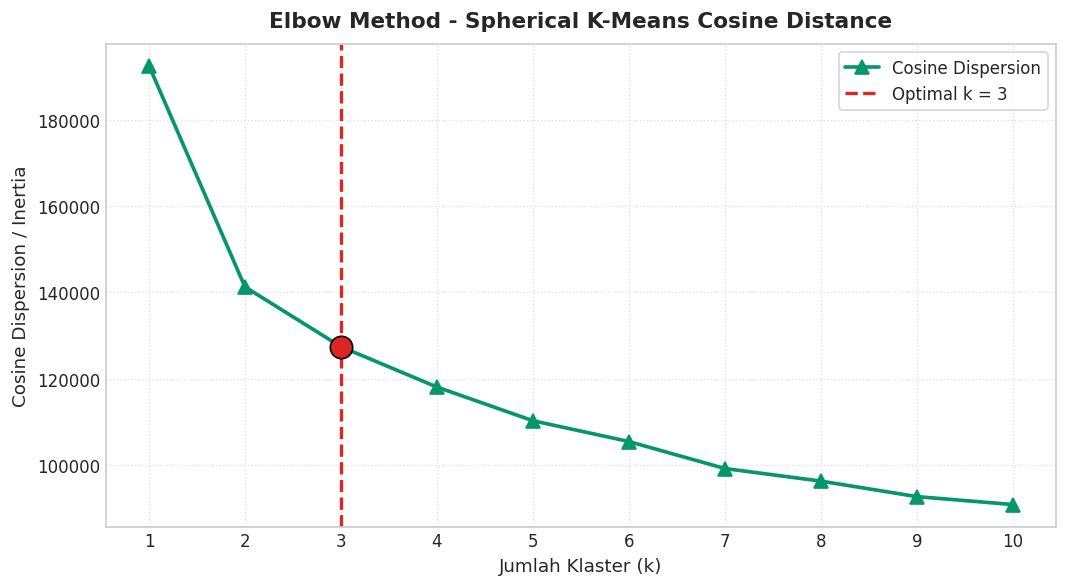

In [ ]:
# Elbow Method Cosine
k_range = list(range(1, 11))
inertia_cosine = []

for k in k_range:
    km = KMeansCosine(n_clusters=k, max_iter=200, random_state=RANDOM_STATE)
    km.fit(X_norm)
    inertia_cosine.append(km.inertia_)
    print(f"  k = {k:<2} | Cosine Inertia = {km.inertia_:,.1f} | iterasi = {km.n_iter_}")

def find_elbow_point(k_vals, inertias):
    p1 = np.array([k_vals[0], inertias[0]])
    p2 = np.array([k_vals[-1], inertias[-1]])
    line_vec = p2 - p1
    line_unit = line_vec / np.linalg.norm(line_vec)
    dists = [
        np.linalg.norm((np.array([k, s]) - p1) - np.dot(np.array([k, s]) - p1, line_unit) * line_unit)
        for k, s in zip(k_vals, inertias)
    ]
    return k_vals[int(np.argmax(dists))]

optimal_k = find_elbow_point(k_range, inertia_cosine)
print(f"[ELBOW] Jumlah klaster optimal terdeteksi: k = {optimal_k}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia_cosine, marker='^', markersize=8, linewidth=2.2, color='#059669', label='Cosine Dispersion')
plt.axvline(x=optimal_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k}')
plt.scatter([optimal_k], [inertia_cosine[optimal_k - 1]], color='#DC2626', s=180, zorder=5, edgecolor='black')
plt.title('Elbow Method - Spherical K-Means Cosine Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Cosine Dispersion / Inertia', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_DIR, "elbow_cosine.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

In [ ]:
# Klastering Final, evaluasi dan implementasi hasil
model_cosine = KMeansCosine(n_clusters=optimal_k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
model_cosine.fit(X_norm)
labels = model_cosine.labels_

sil_score = float(silhouette_score(X_norm, labels, metric='cosine', sample_size=10000, random_state=RANDOM_STATE))
db_score = float(davies_bouldin_score(X_norm, labels))
ch_score = float(calinski_harabasz_score(X_norm, labels))

eval_df = pd.DataFrame([{
    'Distance Metric': 'Cosine Distance (Spherical)',
    'Optimal k': optimal_k,
    'Jumlah Data': X_norm.shape[0],
    'Jumlah Fitur': X_norm.shape[1],
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_cosine.execution_time_, 5),
    'Iterations (↓)': model_cosine.n_iter_,
    'Objective Value (Inertia) (↓)': round(model_cosine.inertia_, 2)
}])

print("\n" + "=" * 80)
print("TABEL EVALUASI K-MEANS COSINE")
print("=" * 80)
print(eval_df.to_string(index=False))
print("=" * 80)

df_clustered = df_features.copy()
df_clustered['Diabetes_012'] = y_label.values
df_clustered['Cluster_Cosine'] = labels

profil = df_clustered.groupby('Cluster_Cosine').mean().round(3)
profil['Jumlah Data'] = df_clustered['Cluster_Cosine'].value_counts().sort_index()
profil['% Diabetes'] = (df_clustered.groupby('Cluster_Cosine')['Diabetes_012'].apply(lambda s: (s == 2).mean() * 100)).round(2)

excel_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_cosine.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    profil.to_excel(writer, sheet_name='Profil_Klaster')
print(f"[SIMPAN] Evaluasi & profil klaster disimpan ke: '{excel_path}'")

csv_path = os.path.join(OUTPUT_DIR, "data_terklaster_cosine.csv")
df_clustered.to_csv(csv_path, index=False)
print(f"[SIMPAN] Data terklaster disimpan ke: '{csv_path}'")


TABEL EVALUASI K-MEANS COSINE
            Distance Metric  Optimal k  Jumlah Data  Jumlah Fitur  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (Inertia) (↓)
Cosine Distance (Spherical)          3       208858            20                0.1513                     3.028                     17993.03                 4.05841              29                      127409.29
[SIMPAN] Evaluasi & profil klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans/evaluasi_kmeans_cosine.xlsx'
[SIMPAN] Data terklaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans/data_terklaster_cosine.csv'


In [ ]:
# Profil Tiap Klaster
profil

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Diabetes_012,Jumlah Data,% Diabetes
Cluster_Cosine,,,,,,,,,,,,,,,,,,,,,
0,0.271,0.315,0.949,27.222,0.366,0.011,0.014,0.836,0.676,0.858,...,2.159,2.728,1.750,0.023,0.000,7.374,5.200,0.145,73786,7.27
1,0.385,0.384,0.940,28.465,0.461,0.015,0.057,0.818,0.567,0.778,...,2.245,1.709,1.391,0.020,1.000,7.386,5.144,0.234,67484,11.71
2,0.746,0.652,0.981,30.966,0.603,0.121,0.264,0.492,0.550,0.710,...,3.573,6.881,12.116,0.564,0.365,9.446,4.520,0.631,67588,31.57


[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans/cluster_cosine.png'


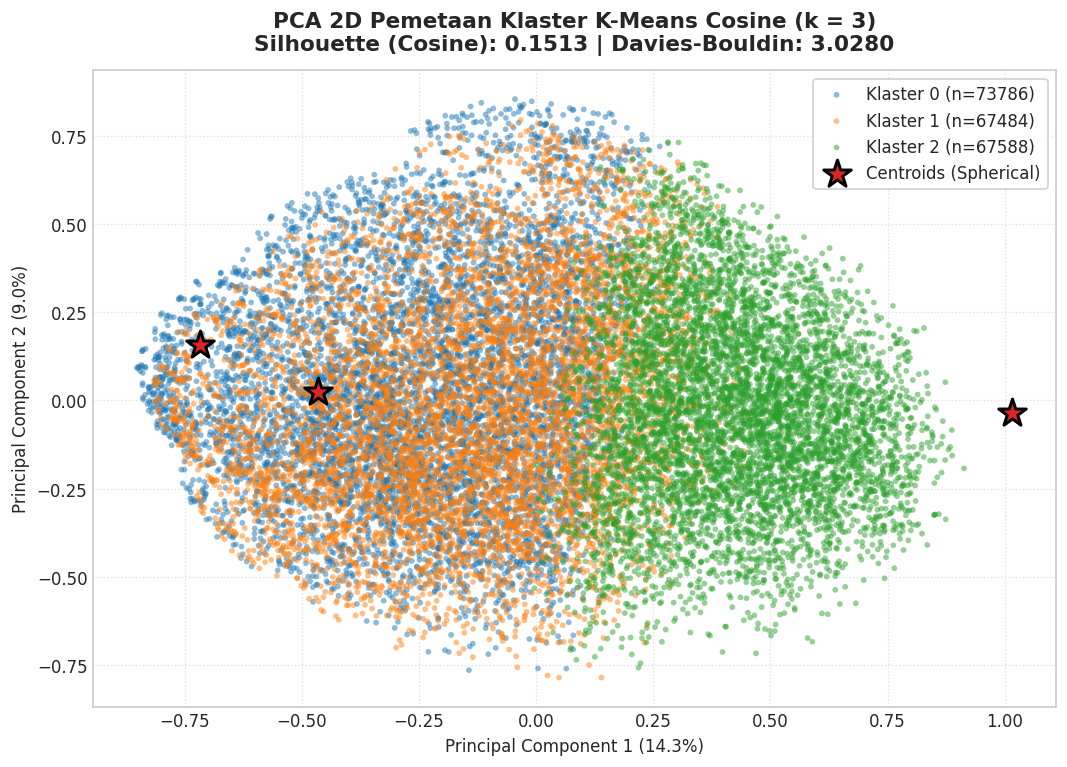

In [ ]:
# Visualisasi
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_norm)
centroids_pca = pca.transform(model_cosine.centroids)

rng_plot = np.random.RandomState(RANDOM_STATE)
n_plot = min(20000, len(X_pca))
idx_plot = rng_plot.choice(len(X_pca), size=n_plot, replace=False)

plt.figure(figsize=(9, 6.5))
palette = sns.color_palette("tab10", optimal_k)

for k in range(optimal_k):
    mask = (labels[idx_plot] == k)
    plt.scatter(
        X_pca[idx_plot][mask, 0], X_pca[idx_plot][mask, 1],
        color=palette[k],
        label=f'Klaster {k} (n={np.sum(labels == k)})',
        alpha=0.5, s=12, edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='*', s=300, c='#DC2626',
    edgecolor='black', linewidth=1.8,
    label='Centroids (Spherical)', zorder=10
)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Cosine (k = {optimal_k})\n'
          f'Silhouette (Cosine): {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_cosine.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

In [ ]:
# Fitur paling berpengaruh
loadings = pd.DataFrame(pca.components_.T, index=df_features.columns, columns=['PC1', 'PC2'])  # bobot fitur di tiap PC
print("Fitur paling berpengaruh di PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(6).round(3))  # 6 teratas PC1
print("\nFitur paling berpengaruh di PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(6).round(3))  # 6 teratas PC2

Fitur paling berpengaruh di PC1:
GenHlth     0.407
HighBP      0.389
DiffWalk    0.340
Age         0.299
HighChol    0.296
PhysHlth    0.275
Name: PC1, dtype: float64

Fitur paling berpengaruh di PC2:
Age             0.459
Fruits          0.435
HighChol        0.370
HighBP          0.345
Veggies         0.311
PhysActivity    0.247
Name: PC2, dtype: float64
